# Solving finite discrete-action games in Stata with `dagamesolve`

### Theory, numerical methods, and examples

**Matthew J. Baker**  
Hunter College and the Graduate Center, CUNY

*Draft: October 2026*

---

## Abstract

`dagamesolve` is a Stata/Mata package for solving finite, simultaneous-move,
discrete-action games of complete information. The package supports an arbitrary
number of players, allows players to have different numbers of actions, searches
for pure, partially mixed, and fully mixed Nash equilibria, and can solve a
sequence of games with a common action structure in a single call.

The computational difficulty is not usually the detection of pure-strategy
equilibria. The hard part is the systematic search for mixed-strategy equilibria.
On a particular support, equilibrium requires solving a system of nonlinear
polynomial equations, and a complete search must also consider the relevant
supports. `dagamesolve` combines dominance reduction, direct checks for pure
equilibria, support enumeration, interval methods for the nonlinear systems,
and Newton refinement. A faster point-based Newton search is also available.

This document explains the representation of games used by the package,
describes the numerical ideas underlying the solver, and provides executable
Stata examples. In particular, it emphasizes a feature that is useful for
econometric applications: a sequence of related games can be constructed and
solved directly in a Stata dataset.


> **About this notebook.**  
> This is intended to be both a technical note and an executable document.
> Markdown cells contain the exposition and equations; Stata cells contain
> examples that can be run directly with a Stata Jupyter kernel. The notebook
> is the master source. A PDF can later be generated from the executed notebook.
>
> The theoretical discussion is adapted from the earlier presentation
> *Finding all solutions to discrete games (using Stata)* and updated to match
> the current `dagamesolve` and `dagamestrats` interfaces.


## 1. Setup

The examples assume that `dagamesolve`, `dagamestrats`, and their dependencies
are already installed or that the notebook is being run from a location where
the development version of the package is on Stata's ado-path.

The package currently depends on `moremata`, `int_utils`, `rowmat_utils`, and
`intsolver`. The `dependency.do` file in the `DaGameSolve` repository installs
the required dependencies.

The following cells install the necessary packages, and then checks the stata environment and locates the two main commands.


In [1]:
ssc install moremata, replace

net install int_utils, ///
    from("https://raw.githubusercontent.com/mbaker21231/int_utils/main/") replace

net install rowmat_utils, ///
    from("https://raw.githubusercontent.com/mbaker21231/rowmat_utils/main/") replace

net install intsolver, ///
    from("https://raw.githubusercontent.com/mbaker21231/IntSolver/main/") replace

* DaGameSolve development version
net install dagamesolve, ///
    from("https://raw.githubusercontent.com/mbaker21231/DaGameSolve/profiling/") replace

* Refresh Mata's library index
mata: mata mlib index


checking moremata consistency and verifying not already installed...
all files already exist and are up to date.

checking int_utils consistency and verifying not already installed...
all files already exist and are up to date.

checking rowmat_utils consistency and verifying not already installed...
all files already exist and are up to date.

checking intsolver consistency and verifying not already installed...
all files already exist and are up to date.

checking dagamesolve consistency and verifying not already installed...
all files already exist and are up to date.

.mlib libraries to be searched are now
    lmatabase;lmataado;lmatabma;lmatacate;lmatacollect;lmatadata;lmataerm;lmataf
> c;lmatagsem;lmatah2o;lmatahetdid;lmataivqreg;lmatajm;lmatalasso;lmatamcmc;lmat
> ameta;lmatami;lmatamixlog;lmatanumlib;lmataopt;lmatapath;lmatapostest;lmatapss
> ;lmatarw;lmatasem;lmatasp;lmatasubexpr;lmatasvy;lmatatab;lmatats;ldagamesolve;
> lamcmc;lcolrspace;lintsolver;lint_utils;livreg2;lmorema

In [2]:
clear all
set more off
set linesize 255

about
which dagamesolve
which dagamestrats






StataNow/SE 19.5 for Windows (64-bit x86-64)
Revision 12 Aug 2026
Copyright 1985-2025 StataCorp LLC

Total physical memory:       16.00 GB
Available physical memory:    3.75 GB

Stata license: Unlimited-user network, expiring 19 Jan 2027
Serial number: 401909310562
  Licensed to: Matthew Baker
               Hunter College

.\dagamesolve.ado
*! dagsolve v1.0.1 MJBaker 21july2014
*! dagsolve v1.0.2 MJBaker 18sep2014
*! dagamesolve v1.0.3 MJBaker 8may2023

.\dagamestrats.ado
*! dagstrats v1.0.0 MJBaker 17July2014
*! dagamestrats v2.0.0 MJBaker 30May2023


In [7]:
%set --permanently graph_format svg

In [8]:
%set --permanently graph_width 900

## 2. Why solve finite games inside Stata?

There are at least three motivations.

First, finding all Nash equilibria of a finite game is a nontrivial computational problem, to put it mildly. Pure-strategy profiles can be checked directly, but mixed strategies require solving nonlinear systems and considering alternative supports. More generally, equilibrium computation is known to be computationally difficult. Nash's theorem guarantees that every finite game possesses at least one mixed-strategy equilibrium, so the central computational problem is not one of deciding whether a solution exists, but of actually finding one. Computing even a single Nash equilibrium of a general finite game is PPAD-complete, a complexity class associated with Brouwer fixed-point problems (Daskalakis, Goldberg, and Papadimitriou, 2009). The problem of recovering the entire equilibrium correspondence is potentially more demanding still: even counting the Nash equilibria of a normal-form game is #P-hard (Conitzer and Sandholm, 2008). 

Second, many empirical models require finding the equilibria for a sequence of games, not just for a single isolated game. Entry models are a natural example. Different markets may contain different payoff shifters, while the underlying strategic structure and structural parameters are common across markets. This repeated-game structure is central to a large empirical literature on static discrete games; see Aradillas-López (2020) for a recent review. Applications include models of entry and market structure in retail, airlines, motels, video rental, and other geographically differentiated industries (Bresnahan and Reiss, 1990, 1991; Berry, 1992; Mazzeo, 2002; Seim, 2006; Jia, 2008; Ciliberto and Tamer, 2009). Bajari, Hong, and Ryan (2010), in particular, develop an estimator for complete-information discrete games in which Nash equilibria must be computed repeatedly as the structural parameters vary. If the game solver is embedded in Stata, game construction, equilibrium computation, data analysis, and eventually estimation can all live in the same environment.

Third, sequences of games are useful and fun to study even outside estimation. Part of my own interest in developing these routines came from teaching graduate microeconomic theory at the CUNY Graduate Center. Some familiar results in game theory become much more provocative when one begins to ask what they imply quantitatively. Wilson's oddness theorem (Wilson, 1971), for example, says that “almost all” finite games have an odd number of Nash equilibria; the exceptional games form a measure-zero set. The qualifier “almost all” naturally raises further questions: how many equilibria does a typical game have, how is that number distributed across games, and where do equilibria appear or disappear as payoffs vary? Related questions arise in McLennan's (2005) work on the expected number of Nash equilibria of a random normal-form game. The magnitudes implied by those results can initially seem surprising, particularly as the numbers of players or available actions grow. Berg and McLennan (2005) pursue this question further for large two-player normal-form games, deriving asymptotic results for the expected number of equilibria. In any event, being able to generate and solve large collections of games provides a simple computational laboratory in which to explore such results directly: one can vary payoff parameters, the number of players, or the number of available actions and examine how equilibrium multiplicity changes.

These were the original motivations for developing ``dagamesolve``: not merely to solve one textbook game, but to make equilibrium computation usable as a component inside a larger empirical workflow. There was, however, an obvious reason not to develop yet another game solver: [**Gambit**](https://www.gambit-project.org/), the long-running and remarkably capable suite of software for the construction and analysis of finite games developed by McKelvey, McLennan, Turocy, and collaborators (2014). Gambit provides a rich collection of equilibrium-computation algorithms, command-line tools, a graphical interface, and a Python API, and it remains the natural benchmark for general-purpose computation in finite games. 
My motivation for writing a separate solver was therefore not that Gambit lacked the relevant game-theoretic machinery. Rather, when this project began, I wanted something that fit more naturally into the way I was already doing empirical work in Stata: games represented directly as observations and variables, sequences of related games solved in a single call, and equilibrium results returned immediately to the working dataset. I also wanted tighter control over the numerical treatment of mixed-strategy solutions, particularly in $N$-player games where support enumeration leads to systems of nonlinear polynomial equations. Gambit itself offers exact rational arithmetic for several two-player methods, while its general polynomial-equilibrium routines necessarily rely on numerical procedures; ``dagamesolve`` took a different route by combining support enumeration with interval arithmetic and subsequent Newton refinement.

The last point of the previous paragraph leads me to a final point, and an apology. ``dagamesolve`` is slow, in large part because of its reliance on interval arithmetic. I will digress on the relative advantages and disadvantages of this approach to solving polynomial systems below, after first describing the nature of the problem. 


## 3. Finite discrete-action games

Consider a complete-information simultaneous-move game with players $i \in N$ players where each player has a set of discrete actions:

$$
A_i=\{1,\ldots,K_i\}.
$$

A mixed strategy for player $i$ is a probability vector

$$
\sigma_i=(\sigma_{i1},\ldots,\sigma_{iK_i}),
\qquad
\sigma_{ik}\geq 0,
\qquad
\sum_{k=1}^{K_i}\sigma_{ik}=1.
$$

A strategy profile $$\sigma^*=(\sigma_1^*,\ldots,\sigma_N^*)$$ is a Nash
equilibrium if no player can increase expected payoff through a unilateral
deviation:

$$
u_i(\sigma_i^*,\sigma_{-i}^*)
\geq
u_i(\sigma_i',\sigma_{-i}^*)
\quad
\text{for every feasible }\sigma_i'.
$$

Pure strategies are special cases in which one action receives a weight of probability equal to unity.
A partially mixed equilibrium has some players mixing and others playing pure
strategies. A fully mixed equilibrium places positive probability on every
action in the relevant support.

Mixed strategies matter computationally as well as theoretically. Nash's
existence theorem permits mixed strategies, and equilibrium search cannot in
general stop after inspecting the finite collection of pure profiles.


### 3.1 A two-action illustration of existence

For intuition, suppose each player has two actions and write $$\sigma_i$$ for
the probability of choosing action 1. One way of motivating the fixed-point
argument is to define the gain from shifting toward action 1,

$$
g_i(\sigma)
=
\max\{u_i(1,\sigma_{-i})-u_i(2,\sigma_{-i}),0\},
$$

and construct a continuous adjustment mapping on the mixed-strategy simplex.
A fixed point of an appropriate mapping has the property that profitable
unilateral adjustments have been exhausted. This connection between Nash equilibrium and fixed points underlies a number of classical computational approaches to equilibrium. 

An alternative formulation, due to McKelvey, turns the same idea into an optimization problem. For a general finite game, let

$$
g_{ij}(\sigma)
=
\max\left\{
u_i(a_{ij},\sigma_{-i})-u_i(\sigma),0
\right\}
$$

denote the positive gain, if any, available to player \(i\) from deviating to pure action \(a_{ij}\). McKelvey constructs the nonnegative function

$$
V(\sigma) =\sum_i\sum_j[g_{ij}(\sigma)]^2.
$$

This function has the useful property that

$$
V(\sigma)=0
\quad\Longleftrightarrow\quad
\sigma\text{ is a Nash equilibrium}.
$$

Thus the computation of Nash equilibrium can alternatively be viewed as a constrained global-minimization problem over the product of the players' mixed-strategy simplices. McKelvey's formulation is particularly attractive because the resulting objective is continuously differentiable, allowing standard numerical optimization methods to be brought to bear on the equilibrium problem (McKelvey, 1998; McKelvey and McLennan, 1996)


The important computational lesson is not the particular fixed-point proof.
It is that equilibrium may lie in the interior of a probability simplex rather
than at one of its vertices. A numerical solver therefore has to deal with
continuous probability variables even though the underlying actions are
discrete.

The optimization formulation does not, however, make the problem of finding all equilibria disappear. Numerical minimization begun from a particular starting point can converge to one basin of attraction while missing others, and a local minimum with a positive value of $V$ is not a Nash equilibrium. Searching for the entire equilibrium correspondence therefore remains a global problem. This distinction—between finding an equilibrium and systematically searching for all equilibria—is central to the design of ``dagamesolve``.


## 4. Representing a game in "list" form

Games are often displayed in normal form. For computation, `dagamesolve` uses a
list representation.

Let $A$ denote a matrix whose columns enumerate the pure-strategy action
profiles and let $\Pi$ contain the corresponding payoffs. If there are $N$
players, both matrices have $N$ rows. The number of columns is

$$
M=\prod_{i=1}^{N} K_i.
$$

For a two-player, two-action game, the action-profile matrix is

$$
A=
\begin{bmatrix}
1&1&2&2\\
1&2&1&2
\end{bmatrix}.
$$

Each column is one complete pure-strategy profile. The payoff matrix has exactly
the same column ordering.

In a Stata dataset, players are observations and action profiles are variables.
The utility command `dagamestrats` constructs the action-profile variables
automatically.


### Example: constructing action profiles

Suppose player 1 has two actions, player 2 has three, and player 3 has two.
There are $2\times3\times2=12$ pure-strategy profiles.


In [9]:
set obs 3

gen game = 1
gen acts = 2
replace acts = 3 in 2

dagamestrats acts, group(game) generate(a)

list game acts a*
return list



Number of observations (_N) was 0, now 3.



(1 real change made)



     +-----------------------------------------------------------------------------------+
     | game   acts   acts   a1   a2   a3   a4   a5   a6   a7   a8   a9   a10   a11   a12 |
     |-----------------------------------------------------------------------------------|
  1. |    1      2      2    1    1    1    1    1    1    2    2    2     2     2     2 |
  2. |    1      3      3    1    1    2    2    3    3    1    1    2     2     3     3 |
  3. |    1      2      2    1    2    1    2    1    2    1    2    1     2     1     2 |
     +-----------------------------------------------------------------------------------+


scalars:
           r(profiles) =  12
             r(groups) =  1


The generated variables `a1`, `a2`, ..., `a12` are the twelve pure-strategy
profiles. Corresponding payoff variables can be created in the same order and
passed to `dagamesolve`.

The same organization extends naturally to a **sequence of games**. Each game
occupies a group of observations, one observation per player. Games in a single
call must have the same number of players and the same action structure, with
corresponding players ordered consistently across games.


## 5. Why mixed-strategy equilibrium is the difficult part

Suppose, for simplicity, that three players each have two actions $a_i \in \{1,2\}$. Let
$p_i$ be the probability that player $i$ chooses action 1.

If all three players mix, each player must be indifferent between the two
actions. For player 1 this condition has the form

$$
\begin{aligned}
& p_2p_3\,u_1(1,1,1)
+p_2(1-p_3)\,u_1(1,1,2) \\
&\quad +(1-p_2)p_3\,u_1(1,2,1)
+(1-p_2)(1-p_3)\,u_1(1,2,2) \\
={}&
p_2p_3\,u_1(2,1,1)
+p_2(1-p_3)\,u_1(2,1,2) \\
&\quad +(1-p_2)p_3\,u_1(2,2,1)
+(1-p_2)(1-p_3)\,u_1(2,2,2).
\end{aligned}
$$

There is one analogous indifference equation for each mixing player. Even in a
binary-action game these equations are polynomial in the other players'
probabilities.

That is only part of the problem. A game may have equilibria on smaller
supports: one player may mix while another plays a pure strategy, or different
players may mix over different subsets of their actions. A systematic search
therefore has to consider candidate supports as well as solve the nonlinear
systems associated with them.

The number of pure profiles and the number of possible supports both grow
rapidly as players and actions are added.


## 6. The solution strategy used by `dagamesolve`

At a high level, the current solver proceeds as follows.

1. **Dominance reduction.** Iteratively eliminate strategies that can be
   removed by the package's dominance checks. In some games this step alone
   solves the game.

2. **Pure-strategy search.** Test the remaining pure profiles for Nash
   equilibrium.

3. **Support enumeration.** Construct candidate subgames/supports for mixed
   and partially mixed equilibria.

4. **Reduce each support.** Apply dominance checks again inside the candidate
   subgame. Supports that cannot contain the desired equilibrium are discarded.

5. **Construct indifference equations.** For every mixing player, expected
   payoffs from actions in the support must agree. One probability per player
   is recovered from the adding-up restriction, so the nonlinear system is
   expressed in the remaining free probabilities.

6. **Solve the nonlinear system.** In the default method, the free probabilities
   initially lie in interval boxes contained in \([0,1]^d\). Interval
   contraction and subdivision are used to search the region systematically.

7. **Newton refinement.** Candidate solution regions are refined to point
   solutions.

8. **Equilibrium verification and consolidation.** Candidate probability
   vectors are checked against equilibrium conditions and nearby numerical
   duplicates are consolidated.

The `fast` option skips the interval-search stage and instead starts Newton
iteration from randomly drawn points in the relevant mixed-strategy simplices.
This is much faster in many problems, but it does not provide the same
systematic search of the strategy space.

The default procedure is therefore best described as a complete-search
procedure **intended to locate all equilibria** of the finite game. As with any
numerical procedure, difficult or degenerate games should be inspected
carefully.


## Digression on Complete Solution of Nonlinear Polynomial Systems

6.1 **Homotopy methods**

Homotopy methods solve a nonlinear system by embedding the problem of interest in a continuous family of related problems. One begins with a system $G(x)=0$ whose solutions are known and constructs a homotopy

$$
H(x,t)=(1-t)G(x)+tF(x)=0,
\qquad t\in[0,1],
$$

where $F(x)=0$ is the system one ultimately wishes to solve. Starting from each known solution at $t=0$, a numerical path-following algorithm traces the corresponding solution as $t$ moves toward one. Under appropriate regularity conditions, the endpoints of these paths at $t=1$ provide the solutions to the original system.

This approach is particularly attractive for polynomial systems because algebraic results can often tell us how many solution paths must be followed. In games, the equilibrium conditions associated with a particular support form a polynomial system, so homotopy continuation can be used to trace candidate equilibria systematically. A major advantage over ordinary Newton iteration is that one is not simply choosing arbitrary starting points and hoping that they lie in the basins of attraction of all the relevant roots. The continuation construction provides a principled collection of paths that can, under suitable conditions, recover all isolated solutions of the polynomial system.

The complications are largely practical. Paths can pass close to singularities, approach one another, or wander through the complex domain even when the economically relevant solutions are real. Careful predictor-corrector methods, endgames, and numerical precision are therefore important. Moreover, polynomial systems may possess many complex solutions that must be tracked even though only a small subset correspond to real probability vectors satisfying equilibrium inequalities. Homotopy methods are consequently powerful and elegant, but they may devote substantial computation to solutions that are ultimately irrelevant for a finite-game problem.

6.2 **Algebraic methods**

Algebraic methods treat the equilibrium conditions as a system of polynomial equations and apply tools from computational algebraic geometry. The best-known examples use Gröbner bases, resultants, or related elimination techniques. The basic idea is to transform a multivariate polynomial system into an equivalent system with a more tractable algebraic structure. In favorable cases, repeated elimination reduces the problem to one univariate polynomial; its roots can then be recovered and substituted backward to obtain the remaining variables.

The attraction of the algebraic approach is that it works with the global structure of the system rather than searching locally from a collection of initial values. It can reveal how many algebraic solutions exist, characterize multiplicities, and sometimes deliver exact or symbolic representations of solutions. This makes it particularly appealing from a theoretical perspective. Since mixed-strategy equilibrium conditions in finite games are polynomial, they fit naturally into this framework, and algebraic methods can in principle enumerate the solutions associated with a candidate support.
The difficulty is that symbolic calculations can grow extraordinarily rapidly as the number and degree of the equations increase. Gröbner-basis computation in particular may suffer from severe intermediate-expression growth, making problems that look modest in economic notation computationally demanding. Exact algebraic computation also produces all algebraic solutions, including complex roots and roots lying outside the probability simplex, which must subsequently be filtered. Thus algebraic methods offer considerable theoretical power, but their computational burden can become substantial as the numbers of players, actions, and candidate supports increase.

6.3 **Interval methods**

Interval methods take a different approach. Instead of representing an unknown probability by a floating-point number $p$, one represents it initially by an interval known to contain it, for example $p\in[0,1]$. Arithmetic operations are then replaced by interval operations constructed so that the resulting interval is guaranteed to contain every value that the corresponding real-valued expression could attain. Applied to a system of equilibrium equations, this makes it possible to evaluate an entire box of candidate probabilities at once.

The key computational advantage is exclusion. Suppose a system contains an equation $f(x)=0$, and interval evaluation over a box $X$ produces

$$
0\notin [f](X).
$$

Then no solution can exist anywhere in that box, and the entire region can be discarded. Boxes that cannot be excluded can be contracted using interval versions of Newton or related consistency operators; if a box remains too large, it can be subdivided and the procedure repeated. The resulting branch-contract-subdivide algorithm progressively eliminates regions that cannot contain roots while isolating regions that may contain them. This makes interval methods particularly attractive when the purpose is not merely to find a root, but to search systematically for all real roots in a bounded domain.
The price of that reliability is computational cost. Interval evaluations can be conservative because repeated occurrences of the same variable are treated as though they varied independently, producing bounds wider than the true range of a function. This “dependency problem” can force additional subdivision and greatly increase the number of boxes that must be examined. Nevertheless, the domain of mixed strategies is naturally bounded—the product of probability simplices—and only real solutions are economically relevant. Those features make interval methods unusually well suited to the objective of dagamesolve: search candidate supports over a known bounded region, rule out regions that cannot contain an equilibrium, isolate the remaining solutions, and then use an ordinary point method such as Newton iteration to refine them.

## 7. A short introduction to interval methods

The interval component is what distinguishes the default mixed-strategy search
from simply running Newton's method from a collection of guesses.

Let

$$
[x]=[\underline{x},\overline{x}]
$$

denote an interval known to contain a scalar \(x\). Basic interval operations
are defined so that the resulting interval contains every possible real result.

Addition:

$$
[a,b]+[c,d]=[a+c,b+d].
$$

Subtraction:

$$
[a,b]-[c,d]=[a-d,b-c].
$$

Multiplication:

$$
[a,b][c,d]
=
[\min(ac,ad,bc,bd),\max(ac,ad,bc,bd)].
$$

Floating-point implementations use **outward rounding**: lower bounds are
rounded downward and upper bounds upward so that numerical rounding does not
incorrectly exclude feasible values.


### 7.1 Inclusion functions and pessimism

Replacing ordinary arithmetic in an expression by interval arithmetic produces
an inclusion function $[f]([x])$ satisfying

$$
f([x])\subseteq [f]([x]).
$$

The inclusion can be wider than the true range because the same variable may
appear repeatedly in the expression. This is often called the dependency
problem or interval pessimism.

For example, if $x\in[-1,2]$, the true range of $x^2$ is $[0,4]$.
Evaluating the algebraically equivalent expression $x\times x$ by naive
interval multiplication gives

$$
[-1,2]\times[-1,2]=[-2,4],
$$

which contains the true range but is wider.

This apparent conservatism is useful for exclusion. If zero is **not** contained
in the interval evaluation of an equation over a box, no root can lie anywhere
inside that box.


### 7.2 Branch, contract, and exclude

Suppose a scalar root is sought on an initial interval $[x]$.

A generic interval search repeats the following operations:

1. Evaluate an interval inclusion of the equation.
2. If $0\notin[f]([x])$, discard the interval.
3. If zero remains possible, attempt to **contract** the interval.
4. If the surviving interval is still too wide, bisect it and place the two
   smaller intervals back on the work list.
5. Continue until no unresolved boxes remain.
6. Refine sufficiently small candidate boxes with a point method such as
   Newton iteration.

In several dimensions, intervals become boxes and the Jacobian becomes an
interval matrix. A Taylor-type inclusion has the schematic form

$$
\mathbf f([\mathbf x])
\subseteq
\mathbf f(\mathbf m)
+
[\mathbf J]([\mathbf x])([\mathbf x]-\mathbf m),
$$

where \(\mathbf m\) is typically a point such as the midpoint of the box.

The interval solver used by `dagamesolve` performs equation-by-equation
contraction and subdivision through the companion `intsolver` package.


## 8. Example 1: a two-player coordination game

Consider the game

| | Player 2: 1 | Player 2: 2 |
|---|---:|---:|
| **Player 1: 1** | \(1,2\) | \(0,0.1\) |
| **Player 1: 2** | \(0,0\) | \(3,1\) |

The game has two pure-strategy equilibria and one mixed equilibrium.

The code below constructs the action profiles with `dagamestrats`, enters the
payoffs in matching profile order, and solves the game.


In [10]:
clear
set obs 2

gen game = 1
gen acts = 2
dagamestrats acts, group(game) generate(s)

* Profile 1: (1,1) -> payoffs (1,2)
gen pay1 = 1
replace pay1 = 2 in 2

* Profile 2: (1,2) -> payoffs (0,.1)
gen pay2 = 0
replace pay2 = .1 in 2

* Profile 3: (2,1) -> payoffs (0,0)
gen pay3 = 0

* Profile 4: (2,2) -> payoffs (3,1)
gen pay4 = 3
replace pay4 = 1 in 2

list game acts s1-s4 pay1-pay4, noobs

dagamesolve s1-s4, group(game) payoffs(pay1-pay4) equilibria(eq)

return list

format eq_* %6.3f
format eq_count %3.0f

format eq_* %6.3f

list eq_1* eq_rets_1, noobs sep(0)
list eq_2* eq_rets_2, noobs sep(0)
list eq_3* eq_rets_3, noobs sep(0)



Number of observations (_N) was 0, now 2.





(1 real change made)


(1 real change made)



(1 real change made)


  +-------------------------------------------------------------+
  | game   acts   s1   s2   s3   s4   pay1   pay2   pay3   pay4 |
  |-------------------------------------------------------------|
  |    1      2    1    1    2    2      1      0      0      3 |
  |    1      2    1    2    1    2      2     .1      0      1 |
  +-------------------------------------------------------------+



scalars:
              r(sdeqs) =  .
             r(mineqs) =  3
             r(maxeqs) =  3
            r(meaneqs) =  3
              r(games) =  1
          r(tolerance) =  1.00000000000e-12
             r(digits) =  1.00000000000e-08
              r(mnits) =  100
             r(coltol) =  .0001
            r(mbwidth) =  .0001
       r(totalactions) =  4

macros:
             r(method) : "complete"

matrices:
      r(playeractions) :  1 x 2





  +---------------------------

If `equilibria(eq)` is specified, strategy probabilities are stored in variables
of the form

$$
\texttt{eq\_q\_p\_a},
$$

where `q` indexes the equilibrium, `p` the player, and `a` the action.
The complete strategy profile is stored on the last player observation for the
game. Variables `eq_rets_q` contain the player-specific equilibrium payoffs,
and `eq_count` records the number of equilibria found.


## 9. Example 2: matching pennies

Matching pennies has no pure-strategy equilibrium. Its unique Nash equilibrium
is fully mixed, with each player placing probability \(1/2\) on each action.

This is a useful minimal example because a solver restricted to pure strategies
would report no equilibrium, while a mixed-strategy solver should recover the
interior solution.


In [11]:
clear
set obs 2

gen game = 1
gen acts = 2
dagamestrats acts, group(game) generate(s)

* Player 1:  1, -1, -1,  1
* Player 2: -1,  1,  1, -1
gen pay1 = cond(_n==1,  1, -1)
gen pay2 = cond(_n==1, -1,  1)
gen pay3 = cond(_n==1, -1,  1)
gen pay4 = cond(_n==1,  1, -1)

dagamesolve s1-s4, group(game) payoffs(pay1-pay4) equilibria(eq)

list eq*, noobs
return list




Number of observations (_N) was 0, now 2.










  +-----------------------------------------------------------------+
  | eq_ret~1   eq_1_1_1   eq_1_1_2   eq_1_2_1   eq_1_2_2   eq_count |
  |-----------------------------------------------------------------|
  |        0          .          .          .          .          . |
  |        0         .5         .5         .5         .5          1 |
  +-----------------------------------------------------------------+


scalars:
              r(sdeqs) =  .
             r(mineqs) =  1
             r(maxeqs) =  1
            r(meaneqs) =  1
              r(games) =  1
          r(tolerance) =  1.00000000000e-12
             r(digits) =  1.00000000000e-08
              r(mnits) =  100
             r(coltol) =  .0001
            r(mbwidth) =  .0001
       r(totalactions) =  4

macros:
             r(method) : "complete"

matrices:
      r(playeractions) :  1 x 2


## 10. Example 3: a three-player coordination game

The earlier presentation used the following three-player game to illustrate
the list representation. In the presentation actions were numbered 0 and 1;
here they are numbered 1 and 2 to match `dagamestrats`.

Only the two unanimous profiles have nonzero payoffs:

\[
\Pi(1,1,1)=(2,1,4),
\qquad
\Pi(2,2,2)=(1.2,2,3),
\]

and the six remaining profiles give all players zero.

The presentation identifies three equilibria in this game. The following cell
constructs and solves it directly.


In [12]:
clear
set obs 3

gen game = 1
gen acts = 2
dagamestrats acts, group(game) generate(s)

forvalues j = 1/8 {
    gen pay`j' = 0
}

* Unanimous action 1
replace pay1 = 2 in 1
replace pay1 = 1 in 2
replace pay1 = 4 in 3

* Unanimous action 2
replace pay8 = 1.2 in 1
replace pay8 = 2   in 2
replace pay8 = 3   in 3

list s1-s8 pay1-pay8, noobs

dagamesolve s1-s8, group(game) payoffs(pay1-pay8) equilibria(eq)

return list

list eq_1* eq_rets_1, noobs sep(0)
list eq_2* eq_rets_2, noobs sep(0)
list eq_3* eq_rets_3, noobs sep(0)




Number of observations (_N) was 0, now 3.





(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)


  +-----------------------------------------------------------------------------------------------+
  | s1   s2   s3   s4   s5   s6   s7   s8   pay1   pay2   pay3   pay4   pay5   pay6   pay7   pay8 |
  |-----------------------------------------------------------------------------------------------|
  |  1    1    1    1    2    2    2    2      2      0      0      0      0      0      0    1.2 |
  |  1    1    2    2    1    1    2    2      1      0      0      0      0      0      0      2 |
  |  1    2    1    2    1    2    1    2      4      0      0      0      0      0      0      3 |
  +-----------------------------------------------------------------------------------------------+



scalars:
              r(sdeqs) =  .
             r(mineqs) =  3
             r(maxeqs) =  3
            r(meaneqs)

## 11. The distinctive feature: solving a sequence of games

For empirical work, it is often more useful to solve a family of related games
than a single game.

Consider a two-firm entry game. Each player chooses **Enter** or **Stay Out**.
Normalize the payoff from staying out to zero. If a firm enters alone, its
payoff is \(\pi>0\). If both firms enter, each receives

$$
\pi-\delta.
$$

Thus:

- when $\delta<\pi$, entry is a dominant action and the unique equilibrium is
  joint entry;
- when $\delta>\pi$, the game has two asymmetric pure equilibria and a mixed
  equilibrium;
- the knife-edge case $\delta=\pi$ is deliberately omitted below.

Instead of solving ten games one at a time, we place all ten in one Stata
dataset and call `dagamesolve` once.


In [13]:
clear
set obs 20

gen game = ceil(_n/2)
bysort game: gen player = _n

gen acts = 2
dagamestrats acts, group(game) generate(s)

* Common monopoly-entry payoff
gen pi = 1

* delta = .5,.6,.7,.8,.9,1.1,1.2,1.3,1.4,1.5
gen delta = .4 + .1*game
replace delta = delta + .1 if delta >= 1

* s1 = (Enter,Enter)
gen pay1 = pi - delta

* s2 = (Enter,StayOut)
gen pay2 = cond(player==1, pi, 0)

* s3 = (StayOut,Enter)
gen pay3 = cond(player==1, 0, pi)

* s4 = (StayOut,StayOut)
gen pay4 = 0

dagamesolve s1-s4, group(game) payoffs(pay1-pay4) equilibria(eq)

list game delta eq_count if player==2, noobs sep(0)




Number of observations (_N) was 0, now 20.







(10 real changes made)







  +-------------------------+
  | game   delta   eq_count |
  |-------------------------|
  |    1      .5          1 |
  |    2      .6          1 |
  |    3      .7          1 |
  |    4      .8          1 |
  |    5      .9          1 |
  |    6     1.1          3 |
  |    7     1.2          3 |
  |    8     1.3          3 |
  |    9     1.4          3 |
  |   10     1.5          3 |
  +-------------------------+


The equilibrium count should change as $\delta$ crosses $\pi$. Because the
equilibrium count is stored on the last observation of each game, a simple plot
can summarize the sequence.


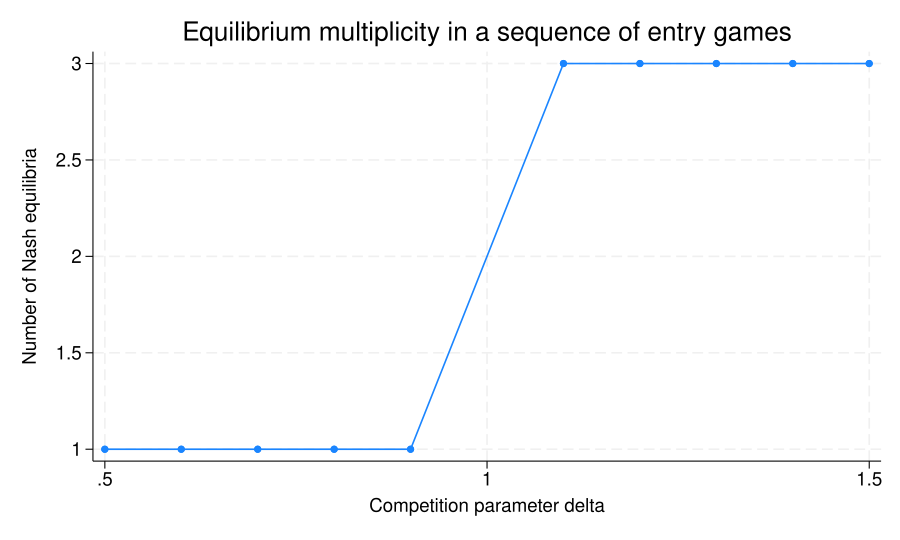

In [15]:
sort delta

twoway connected eq_count delta if player==2, ///
    ytitle("Number of Nash equilibria") ///
    xtitle("Competition parameter delta") ///
    title("Equilibrium multiplicity in a sequence of entry games")

This example captures an important intended use of the software. A researcher
can generate game-specific payoffs from covariates or parameter values, solve
the entire sequence, and then feed equilibrium objects into subsequent
analysis without moving between Stata and a stand-alone game-theory program.


## 12. Complete search, `fast`, and `pureonly`

The default mixed-strategy method uses interval search followed by Newton
refinement. Two useful alternatives are available.

### `fast`

With `fast`, the interval-search stage is skipped. For each support, random
points are drawn from the relevant mixed-strategy simplices and used as starting
values for Newton iteration. `randompoints(#)` controls the number of starts.

This may be dramatically faster, but it can miss equilibria if none of the
random starting points fall in a useful basin of attraction.

### `pureonly`

With `pureonly`, no mixed-strategy systems are solved. This is useful when only
pure equilibria are substantively relevant or when one wants a quick
preliminary diagnostic.


In [16]:
set seed 5150

dagamesolve s1-s4, group(game) payoffs(pay1-pay4) ///
    equilibria(ef) fast randompoints(200)

dagamesolve s1-s4, group(game) payoffs(pay1-pay4) ///
    equilibria(ep) pureonly

list game delta eq_count ef_count ep_count if player==2, noobs sep(0)







  +-----------------------------------------------+
  | game   delta   eq_count   ef_count   ep_count |
  |-----------------------------------------------|
  |    1      .5          1          1          1 |
  |    2      .6          1          1          1 |
  |    3      .7          1          1          1 |
  |    4      .8          1          1          1 |
  |    5      .9          1          1          1 |
  |    6     1.1          3          3          2 |
  |    7     1.2          3          3          2 |
  |    8     1.3          3          3          2 |
  |    9     1.4          3          3          2 |
  |   10     1.5          3          3          2 |
  +-----------------------------------------------+


For this simple sequence one would expect the default and sufficiently thorough
`fast` searches to agree. The `pureonly` count differs when a mixed equilibrium
is present. Agreement in a simple example should not be interpreted as a
general completeness guarantee for `fast`.


## 13. Numerical controls

The default complete-search settings are:

| Option | Default | Role |
|---|---:|---|
| `mbwidth(#)` | `1e-4` | Target maximum interval-box width before refinement |
| `tolerance(#)` | `1e-12` | Newton convergence tolerance |
| `coltol(#)` | `1e-4` | Tolerance for consolidating numerically nearby solutions |
| `digits(#)` | `1e-8` | Precision parameter used in interval outward rounding |
| `mnits(#)` | `100` | Maximum Newton iterations |

For the fast search,

| Option | Default | Role |
|---|---:|---|
| `randompoints(#)` | `50` | Random Newton starting points for each candidate support |
| `tolerance(#)` | `1e-12` | Newton convergence tolerance |
| `mnits(#)` | `100` | Maximum Newton iterations |

These parameters control different parts of the numerical procedure and should
not be interpreted as interchangeable measures of "accuracy." In particular,
`mbwidth()` concerns the interval search, `tolerance()` concerns Newton
iteration, `coltol()` concerns consolidation of candidate solutions, and
`digits()` concerns interval arithmetic.


## 14. A sequence-of-games regression test

The package's test suite contains a useful compact example: three two-player
games are stacked in one dataset.

1. a coordination game with three equilibria;
2. a dominant-strategy game with one equilibrium;
3. matching pennies with one mixed equilibrium.

The example below is adapted directly from the current regression test and is
useful both pedagogically and as a reproducibility check.


In [17]:
clear
set obs 6

gen game = ceil(_n/2)
bysort game: gen player = _n

gen acts = 2
dagamestrats acts, group(game) generate(s)

forvalues j = 1/4 {
    gen pay`j' = .
}

* Game 1: coordination
replace pay1 = 1 if game==1
replace pay2 = 0 if game==1
replace pay3 = 0 if game==1
replace pay4 = 1 if game==1

* Game 2: action 2 strictly dominant for both players
replace pay1 = 3 if game==2 & player==1
replace pay2 = 0 if game==2 & player==1
replace pay3 = 5 if game==2 & player==1
replace pay4 = 1 if game==2 & player==1

replace pay1 = 3 if game==2 & player==2
replace pay2 = 5 if game==2 & player==2
replace pay3 = 0 if game==2 & player==2
replace pay4 = 1 if game==2 & player==2

* Game 3: matching pennies
replace pay1 =  1 if game==3 & player==1
replace pay2 = -1 if game==3 & player==1
replace pay3 = -1 if game==3 & player==1
replace pay4 =  1 if game==3 & player==1

replace pay1 = -1 if game==3 & player==2
replace pay2 =  1 if game==3 & player==2
replace pay3 =  1 if game==3 & player==2
replace pay4 = -1 if game==3 & player==2

dagamesolve s1-s4, group(game) payoffs(pay1-pay4) equilibria(e)

list game player e_count if !missing(e_count), noobs sep(0)

assert e_count==3 if game==1 & player==2
assert e_count==1 if game==2 & player==2
assert e_count==1 if game==3 & player==2

display as result "PASS: sequence of games solved correctly"




Number of observations (_N) was 0, now 6.





(6 missing values generated)
(6 missing values generated)
(6 missing values generated)
(6 missing values generated)

(2 real changes made)

(2 real changes made)

(2 real changes made)

(2 real changes made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)

(1 real change made)



  +-------------------------+
  | game   player   e_count |
  |-------------------------|
  |    1        2         3 |
  |    2        2         1 |
  |    3        2         1 |
  +-------------------------+




PASS: sequence of games solved correctly


## 15. Stored results

`dagamesolve` stores summary information in `r()` in addition to the variables
it creates in the dataset.

Core stored results include:

- `r(playeractions)`: number of actions available to each player;
- `r(totalactions)`: total number of player-actions;
- `r(method)`: `complete` or `newton`;
- `r(games)`: number of games solved;
- `r(meaneqs)`: mean equilibrium count across games;
- `r(maxeqs)`: maximum equilibrium count;
- `r(mineqs)`: minimum equilibrium count;
- `r(sdeqs)`: standard deviation of equilibrium counts.

The complete method also records the interval and Newton settings. The fast
method records the number of random starting points.

Because the equilibrium probability variables remain in the dataset, they can
be reshaped, summarized, merged to market-level data, or used in subsequent
programs without leaving Stata.


In [18]:
return list



scalars:
              r(sdeqs) =  1.154700538379252
             r(mineqs) =  1
             r(maxeqs) =  3
            r(meaneqs) =  1.666666666666667
              r(games) =  3
          r(tolerance) =  1.00000000000e-12
             r(digits) =  1.00000000000e-08
              r(mnits) =  100
             r(coltol) =  .0001
            r(mbwidth) =  .0001
       r(totalactions) =  4

macros:
             r(method) : "complete"

matrices:
      r(playeractions) :  1 x 2


## 16. Computational considerations

The computational burden grows quickly for two related reasons.

First, the number of pure profiles is

$$
\prod_i K_i.
$$

Second, mixed-equilibrium search requires consideration of candidate supports.
For each surviving support, the solver constructs and solves a nonlinear system.
Adding players or actions therefore affects both the size of individual
systems and the number of systems that may have to be considered.

Interval methods are intentionally more demanding than point-based Newton
searches. Their advantage is that boxes can be ruled out over entire regions
of the strategy space rather than only explored from selected starting points.

Several practical implications follow:

- use `pureonly` when mixed equilibria are irrelevant;
- use `fast` when exploratory speed matters more than systematic coverage;
- use the default method when the goal is a systematic search for pure and
  mixed equilibria;
- exploit sequences of games when many games have the same action structure;
- inspect difficult, degenerate, or nearly duplicate equilibria carefully;
- report numerical settings in applications where equilibrium multiplicity is
  substantively important.


## 17. What this makes possible for empirical work

The original motivation for these routines was closely connected to empirical
models of strategic interaction.

Suppose market $m$ is associated with a game whose payoff primitives depend
on observed covariates $X_m$ and parameters $\theta$:

$$
\Pi_m=\Pi(X_m,\theta).
$$

For a trial value of $\theta$, one can:

1. construct the payoff matrix for every market;
2. solve the sequence of games;
3. obtain the equilibrium correspondence market by market;
4. compare predicted equilibrium behavior with observed outcomes;
5. embed the calculation in an estimation, simulation, or counterfactual
   procedure.

The computational problem is therefore not incidental. When a structural model
permits multiple equilibria, the ability to obtain the equilibrium
correspondence repeatedly can be an essential piece of the empirical method.

Bajari, Hong, and Ryan (2010) provide an important example of the broader
connection between discrete games and econometric analysis.


## 18. Conclusions

`dagamesolve` is designed to make finite-game equilibrium computation available
inside a data-analysis environment.

The easy part of a finite game is often the part one sees in a textbook:
enumerate a few pure profiles and check unilateral deviations. The difficult
part is what happens once mixed and partially mixed equilibria are admitted.
The problem becomes one of support enumeration and nonlinear equation solving.

The package addresses that problem by combining game-specific reductions with
general numerical tools:

- dominance reduction;
- direct pure-strategy checks;
- support enumeration;
- interval contraction and subdivision;
- Newton refinement;
- candidate verification and consolidation.

The ability to apply the same machinery to a sequence of games is particularly
useful for applications in which payoffs vary across markets, observations, or
counterfactual parameter values.

The present notebook is intended to serve simultaneously as documentation,
a reproducible collection of examples, and a technical description of the
solver.


## References

Aradillas-López, Andrés. 2020. “The Econometrics of Static Games.” _Annual Review of Economics_ 12: 135–165.

Bajari, Patrick, Han Hong, John Krainer, and Denis Nekipelov. 2010. “Estimating Static Models of Strategic Interactions.” _Journal of Business & Economic Statistics_ 28(4): 469–482.

Bajari, Patrick, Han Hong, and Stephen P. Ryan. 2010. “Identification and Estimation of a Discrete Game of Complete Information.” _Econometrica_ 78(5): 1529–1568.

Berg, Johannes, and Andrew McLennan. 2005. “Asymptotic Expected Number of Nash Equilibria of Two-Player Normal Form Games.” _Games and Economic Behavior_ 51(2): 264–295.

Berry, Steven T. 1992. “Estimation of a Model of Entry in the Airline Industry.” _Econometrica_ 60(4): 889–917.

Bresnahan, Timothy F., and Peter C. Reiss. 1990. “Entry in Monopoly Market.” _Review of Economic Studies_ 57(4): 531–553.

Bresnahan, Timothy F., and Peter C. Reiss. 1991. “Entry and Competition in Concentrated Markets.” _Journal of Political Economy_ 99(5): 977–1009.

Ciliberto, Federico, and Elie Tamer. 2009. “Market Structure and Multiple Equilibria in Airline Markets.” _Econometrica_ 77(6): 1791–1828.

Conitzer, Vincent, and Tuomas Sandholm. 2008. “New Complexity Results about Nash Equilibria.” _Games and Economic Behavior_ 63(2): 621–641. 

Daskalakis, Constantinos, Paul W. Goldberg, and Christos H. Papadimitriou. 2009. “The Complexity of Computing a Nash Equilibrium.” _SIAM Journal on Computing_ 39(1): 195–259. 

Etessami, Kousha, and Mihalis Yannakakis. 2010. “On the Complexity of Nash Equilibria and Other Fixed Points.” _SIAM Journal on Computing_ 39(6): 2531–2597. 

Gilboa, Itzhak, and Eitan Zemel. 1989. “Nash and Correlated Equilibria: Some Complexity Considerations.” _Games and Economic Behavior_ 1(1): 80–93. 

Grieco, Paul L. E. 2014. “Discrete Games with Flexible Information Structures: An Application to Local Grocery Markets.” _RAND Journal of Economics_ 45(2): 303–340.

Jaulin, Luc, Michel Kieffer, Olivier Didrit, and Eric Walter. 2001. _Applied Interval Analysis_. London: Springer.

Jia, Panle. 2008. “What Happens When Wal-Mart Comes to Town: An Empirical Analysis of the Discount Retailing Industry.” _Econometrica_ 76(6): 1263–1316.

Mazzeo, Michael J. 2002. “Product Choice and Oligopoly Market Structure.” _RAND Journal of Economics_ 33(2): 221–242.

McKelvey, Richard D. 1998. “A Liapunov Function for Nash Equilibria.” _Social Science Working Paper 953_, California Institute of Technology.

McKelvey, Richard D., and Andrew McLennan. 1996. “Computation of Equilibria in Finite Games.” In _Handbook of Computational Economics_, Vol. 1, edited by Hans M. Amman, David A. Kendrick, and John Rust, 87–142. Amsterdam: North-Holland.

McKelvey, Richard D., Andrew M. McLennan, and Theodore L. Turocy. 2014. _Gambit: Software Tools for Game Theory, Version 14.1.1._ The Gambit Project.

McLennan, Andrew. 2005. “The Expected Number of Nash Equilibria of a Normal Form Game.” _Econometrica_ 73(1): 141–174.

de Paula, Áureo. 2013. “Econometric Analysis of Games with Multiple Equilibria.” _Annual Review of Economics_ 5: 107–131.

Seim, Katja. 2006. “An Empirical Model of Firm Entry with Endogenous Product-Type Choices.” _RAND Journal of Economics_ 37(3): 619–640.

Sweeting, Andrew. 2009. “The Strategic Timing Incentives of Commercial Radio Stations: An Empirical Analysis Using Multiple Equilibria.” _RAND Journal of Economics_ 40(4): 710–742.

Wilson, Robert. 1971. “Computing Equilibria of N-Person Games.” _SIAM Journal on Applied Mathematics_ 21(1): 80–87.